In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("ecommerce.csv", low_memory=False)

# Convert dates securely
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

# Clean and convert numeric columns efficiently
numeric_cols = ["Sales", "Quantity", "Discount", "Profit", "Shipping Cost", "Aging"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.replace("$", "", regex=False)
            .str.replace("₹", "", regex=False)
            .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Batch convert categorical columns
categorical_cols = [
    "Order ID", "Ship Mode", "Product Category", "Product", 
    "Order Priority", "Customer ID", "Customer Name", 
    "Segment", "City", "State", "Country", "Region", "Months"
]
df[categorical_cols] = df[categorical_cols].astype("category")

# Drop critical missing entries if any
df.dropna(subset=["Sales", "Profit", "Order Date"], inplace=True)

# Print final dtypes once
print(df.dtypes)

C:\Users\DELL\AppData\Local\Temp\ipykernel_20624\379031466.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")


Order ID                  category
Order Date          datetime64[us]
Ship Date           datetime64[us]
Aging                      float64
Ship Mode                 category
Product Category          category
Product                   category
Sales                      float64
Quantity                   float64
Discount                   float64
Profit                     float64
Shipping Cost              float64
Order Priority            category
Customer ID               category
Customer Name             category
Segment                   category
City                      category
State                     category
Country                   category
Region                    category
Months                    category
dtype: object


In [6]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_quantity = df['Quantity'].sum()
total_shipping = df['Shipping Cost'].sum()

print("### 1. Overall Sales Performance ###")
print(f"Total Sales:         ${total_sales:,.2f}")
print(f"Total Profit:        ${total_profit:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Total Shipping Cost: ${total_shipping:,.2f}")

### 1. Overall Sales Performance ###
Total Sales:         $3,157,626.00
Total Profit:        $1,469,767.90
Total Quantity Sold: 60,737.0
Total Shipping Cost: $146,989.70


C:\Users\DELL\AppData\Local\Temp\ipykernel_20624\499221631.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='Sales', ylabel='Product'>

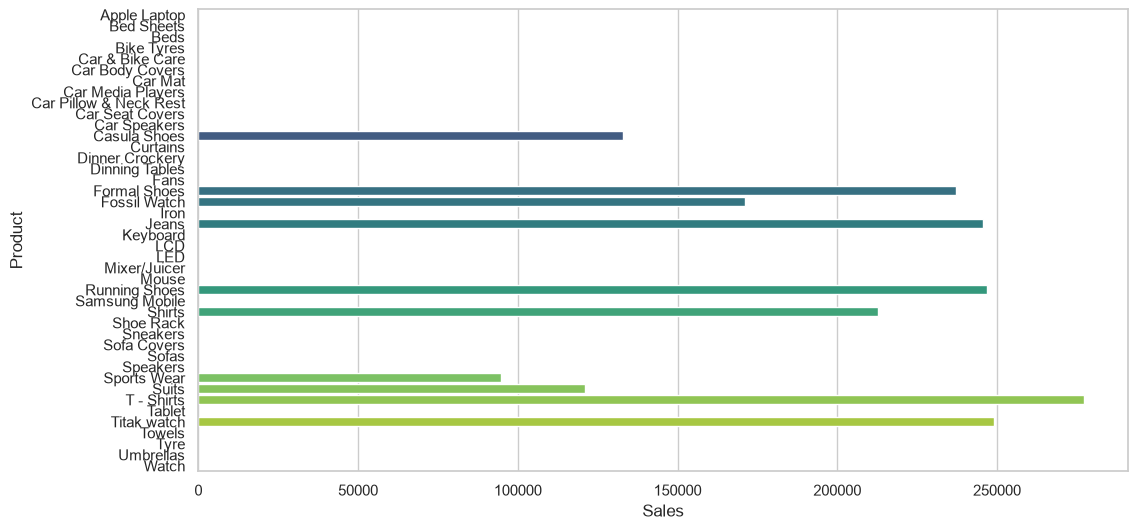

In [10]:
sns.barplot(
    data=top_10_products,
    x='Sales',
    y='Product',
    palette='viridis'
)

In [11]:
category_analysis = df.groupby('Product Category', observed=True).agg({'Sales':'sum', 'Profit':'sum', 'Quantity':'sum'}).reset_index()

print("### 3. Product Category Analysis ###")
print(category_analysis.to_string(index=False))

### 3. Product Category Analysis ###
  Product Category     Sales   Profit  Quantity
Auto & Accessories  423773.0 186559.6    8696.0
        Electronic  157751.0  69959.4    3277.0
           Fashion 2059055.0 983667.2   36468.0
  Home & Furniture  517047.0 229581.7   12296.0


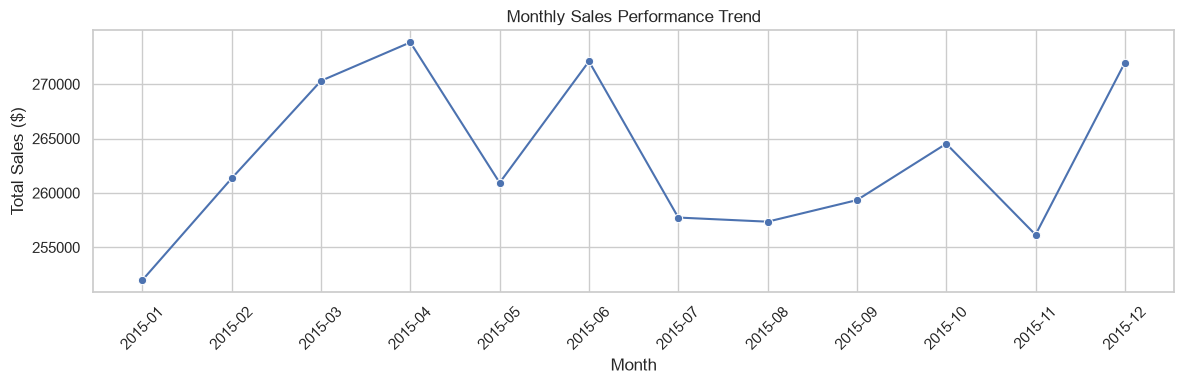

In [12]:
monthly_trend = df.groupby('YearMonth')['Sales'].sum().reset_index()

plt.figure(figsize=(12, 4))
sns.lineplot(data=monthly_trend, x='YearMonth', y='Sales', marker='o', color='b')
plt.xticks(rotation=45)
plt.title('Monthly Sales Performance Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

In [13]:
regional_analysis = df.groupby('Region', observed=True).agg({'Sales':'sum', 'Profit':'sum'}).sort_values(by='Profit', ascending=False).reset_index()

print("### 5. Regional Sales Analysis ###")
print(regional_analysis.to_string(index=False))

### 5. Regional Sales Analysis ###
        Region    Sales   Profit
       Central 671868.0 313723.9
         South 409418.0 189540.3
          EMEA 307920.0 143578.4
         North 291213.0 135489.8
        Africa 279796.0 130112.4
       Oceania 217869.0 101297.7
Southeast Asia 197763.0  93126.4
          West 197560.0  91844.2
          East 174977.0  81322.1
    North Asia 154438.0  72482.7
  Central Asia 123876.0  56915.8
     Caribbean 106962.0  49636.2
        Canada  23966.0  10698.0


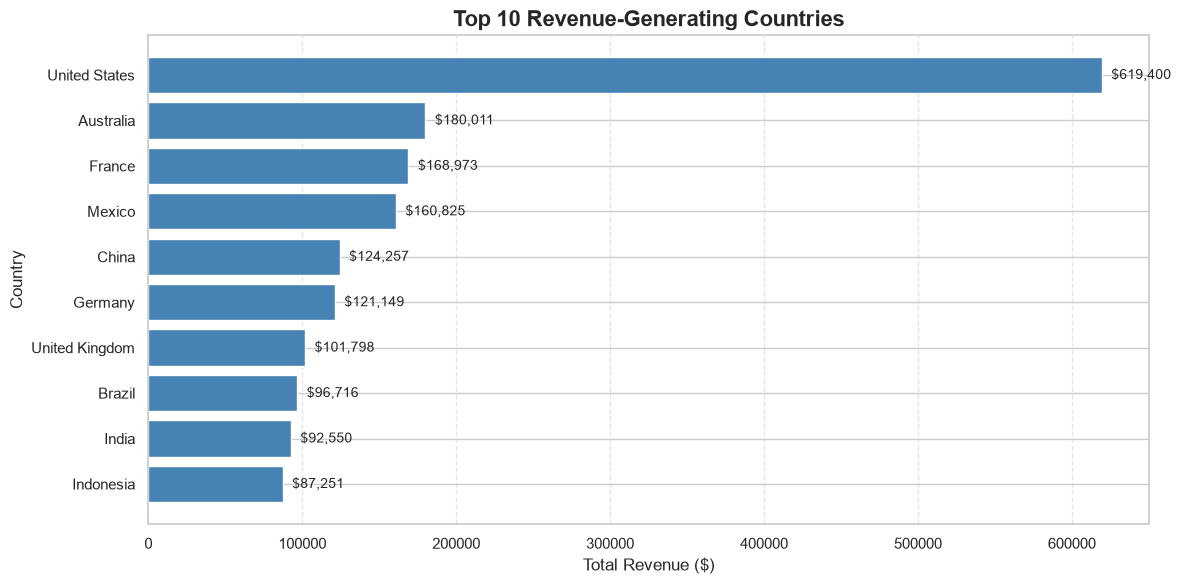

In [16]:
import matplotlib.pyplot as plt

# Top 10 countries by revenue
top_10_countries = (
    df.groupby('Country', observed=True)['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12, 6))

bars = plt.barh(
    top_10_countries.index,
    top_10_countries.values,
    color='steelblue'
)

# Highest revenue at the top
plt.gca().invert_yaxis()

# Add value labels
for bar in bars:
    plt.text(
        bar.get_width() + max(top_10_countries.values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"${bar.get_width():,.0f}",
        va='center',
        fontsize=10
    )

plt.title("Top 10 Revenue-Generating Countries", fontsize=16, fontweight='bold')
plt.xlabel("Total Revenue ($)", fontsize=12)
plt.ylabel("Country", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

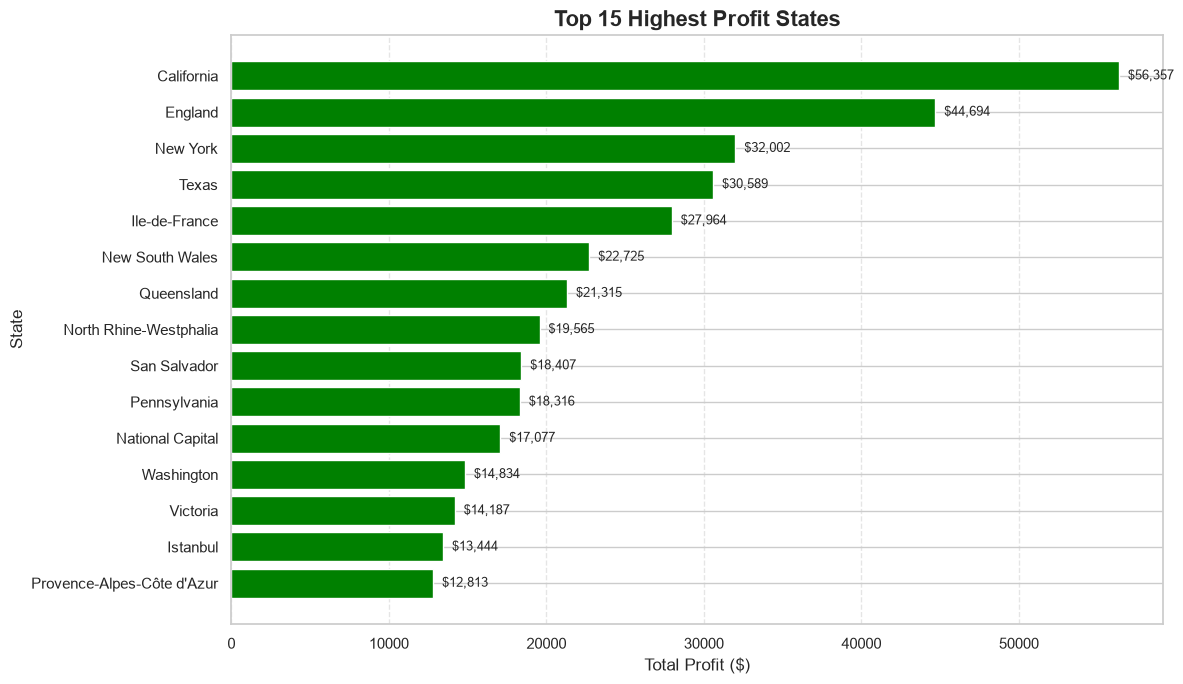

In [17]:
import matplotlib.pyplot as plt

# Top 15 profit states
top_states = (
    df.groupby(['State', 'Country'], observed=True)['Profit']
      .sum()
      .reset_index()
      .sort_values(by='Profit', ascending=False)
      .head(15)
)

plt.figure(figsize=(12, 7))
bars = plt.barh(top_states['State'], top_states['Profit'], color='green')

plt.gca().invert_yaxis()

# Add profit labels
for bar in bars:
    plt.text(bar.get_width() + top_states['Profit'].max()*0.01,
             bar.get_y() + bar.get_height()/2,
             f"${bar.get_width():,.0f}",
             va='center',
             fontsize=9)

plt.title("Top 15 Highest Profit States", fontsize=16, fontweight='bold')
plt.xlabel("Total Profit ($)")
plt.ylabel("State")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

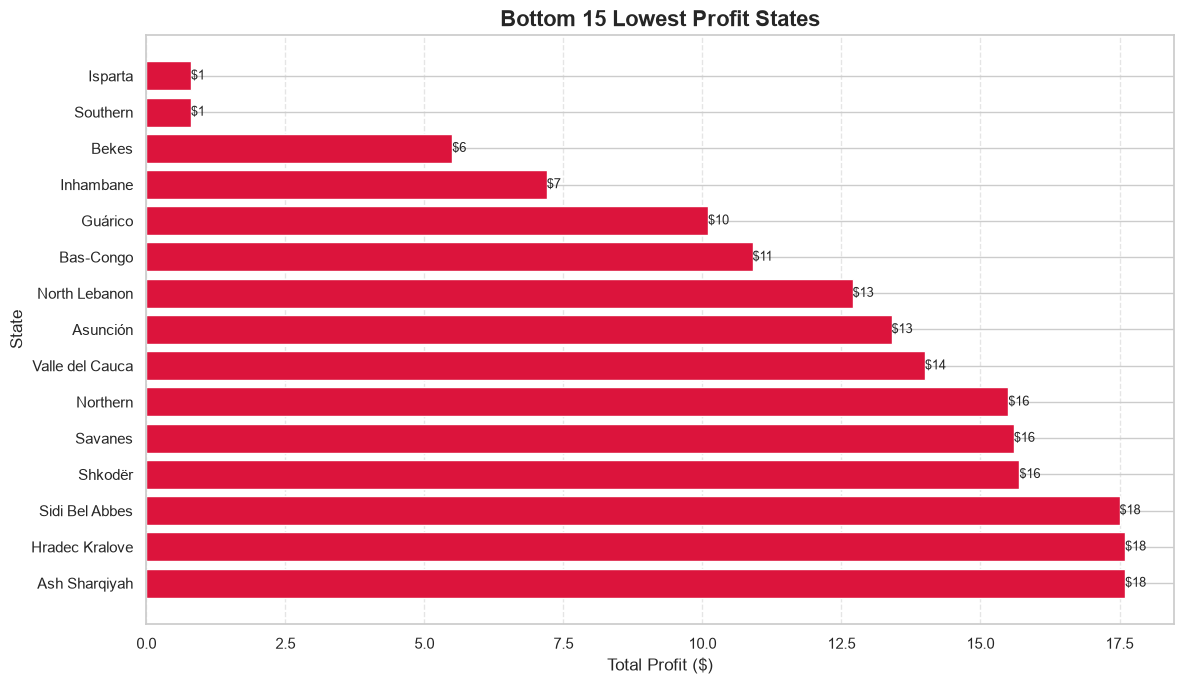

In [18]:
# Bottom 15 profit states
bottom_states = (
    df.groupby(['State', 'Country'], observed=True)['Profit']
      .sum()
      .reset_index()
      .sort_values(by='Profit')
      .head(15)
)

plt.figure(figsize=(12, 7))
bars = plt.barh(bottom_states['State'], bottom_states['Profit'], color='crimson')

plt.gca().invert_yaxis()

# Add profit labels
for bar in bars:
    plt.text(bar.get_width(),
             bar.get_y() + bar.get_height()/2,
             f"${bar.get_width():,.0f}",
             va='center',
             fontsize=9)

plt.title("Bottom 15 Lowest Profit States", fontsize=16, fontweight='bold')
plt.xlabel("Total Profit ($)")
plt.ylabel("State")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

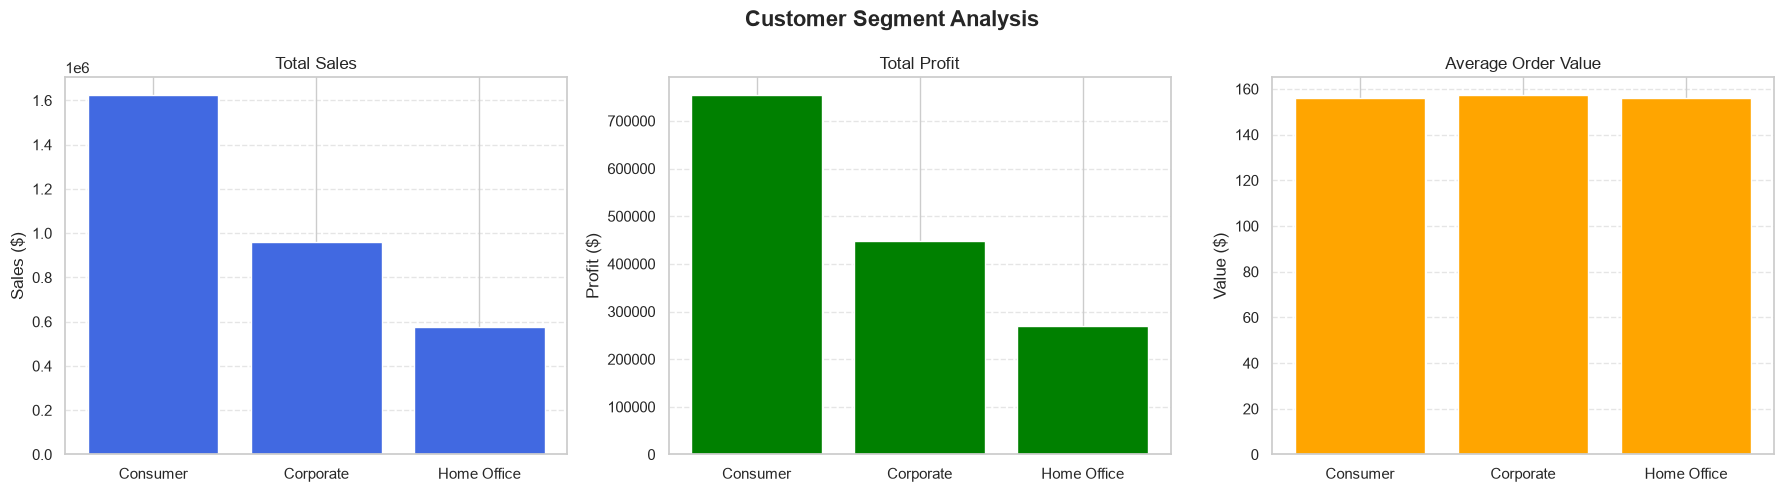

In [19]:
import matplotlib.pyplot as plt

# Customer Segment Analysis
order_summary = (
    df.groupby(['Order ID', 'Segment'], observed=True)
      .agg({'Sales': 'sum', 'Profit': 'sum'})
      .reset_index()
)

segment_analysis = (
    order_summary.groupby('Segment', observed=True)
    .agg(
        Total_Sales=('Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Average_Order_Value=('Sales', 'mean')
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total Sales
axes[0].bar(segment_analysis['Segment'],
            segment_analysis['Total_Sales'],
            color='royalblue')
axes[0].set_title('Total Sales')
axes[0].set_ylabel('Sales ($)')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Total Profit
axes[1].bar(segment_analysis['Segment'],
            segment_analysis['Total_Profit'],
            color='green')
axes[1].set_title('Total Profit')
axes[1].set_ylabel('Profit ($)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Average Order Value
axes[2].bar(segment_analysis['Segment'],
            segment_analysis['Average_Order_Value'],
            color='orange')
axes[2].set_title('Average Order Value')
axes[2].set_ylabel('Value ($)')
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Customer Segment Analysis", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

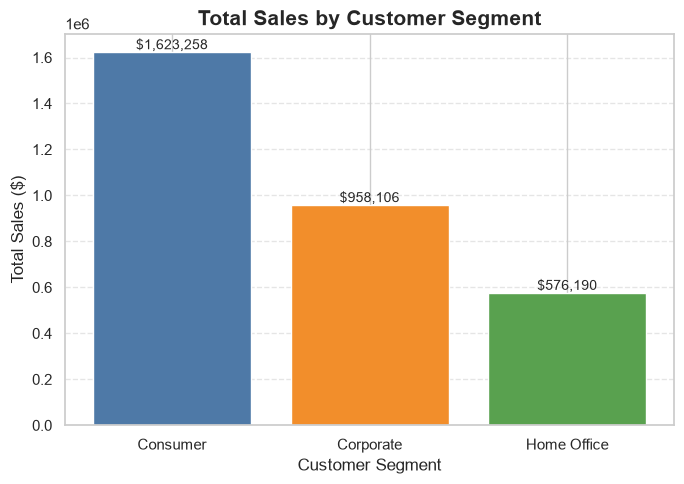

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

bars = plt.bar(
    segment_analysis['Segment'],
    segment_analysis['Total_Sales'],
    color=['#4E79A7', '#F28E2B', '#59A14F']
)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Total Sales by Customer Segment", fontsize=15, fontweight='bold')
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales ($)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

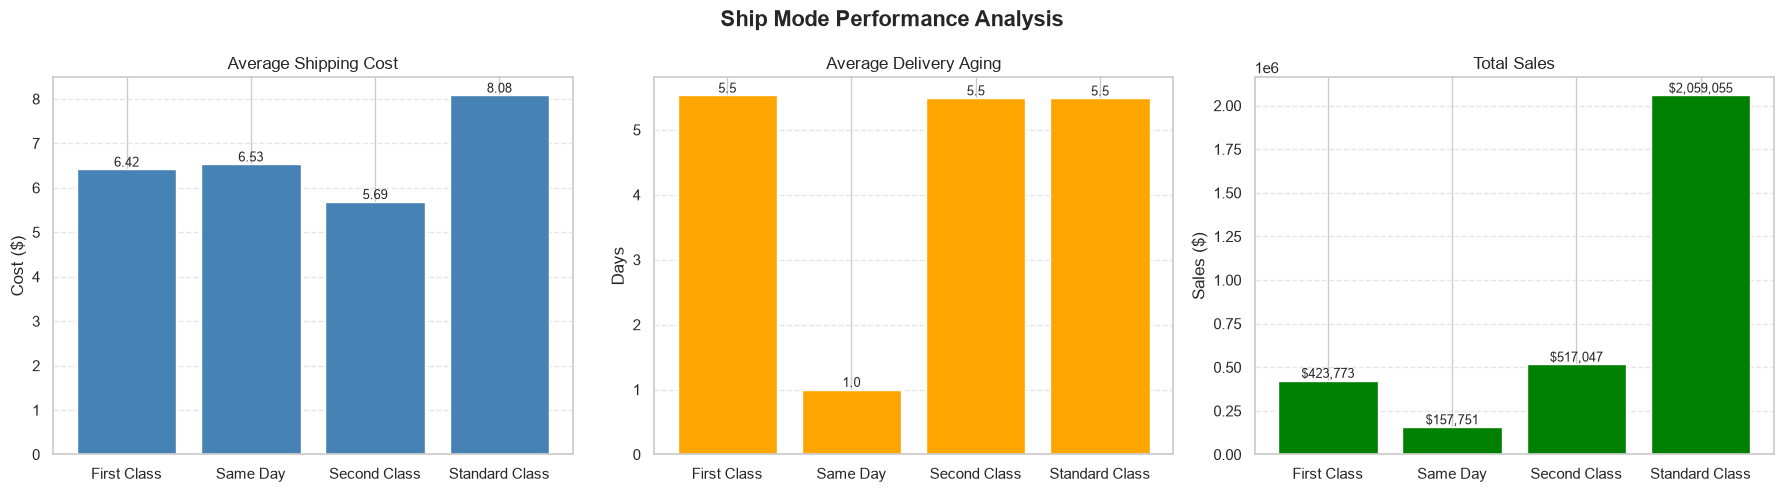

In [21]:
import matplotlib.pyplot as plt

# Ship Mode Performance
ship_mode_analysis = (
    df.groupby('Ship Mode', observed=True)
      .agg(
          Average_Shipping_Cost=('Shipping Cost', 'mean'),
          Average_Delivery_Aging=('Aging', 'mean'),
          Total_Sales=('Sales', 'sum')
      )
      .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Average Shipping Cost
bars1 = axes[0].bar(
    ship_mode_analysis['Ship Mode'],
    ship_mode_analysis['Average_Shipping_Cost'],
    color='steelblue'
)
axes[0].set_title('Average Shipping Cost')
axes[0].set_ylabel('Cost ($)')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars1:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

# Average Delivery Aging
bars2 = axes[1].bar(
    ship_mode_analysis['Ship Mode'],
    ship_mode_analysis['Average_Delivery_Aging'],
    color='orange'
)
axes[1].set_title('Average Delivery Aging')
axes[1].set_ylabel('Days')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars2:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

# Total Sales
bars3 = axes[2].bar(
    ship_mode_analysis['Ship Mode'],
    ship_mode_analysis['Total_Sales'],
    color='green'
)
axes[2].set_title('Total Sales')
axes[2].set_ylabel('Sales ($)')
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars3:
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.suptitle("Ship Mode Performance Analysis", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

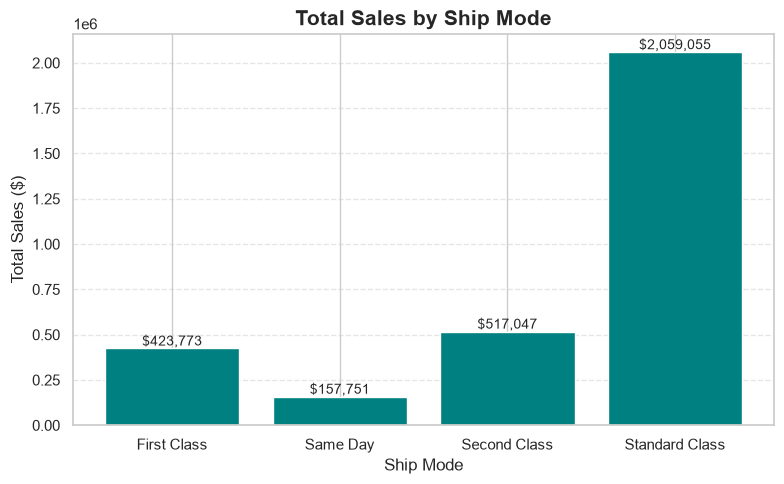

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.bar(
    ship_mode_analysis['Ship Mode'],
    ship_mode_analysis['Total_Sales'],
    color='teal'
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Total Sales by Ship Mode", fontsize=15, fontweight='bold')
plt.xlabel("Ship Mode")
plt.ylabel("Total Sales ($)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

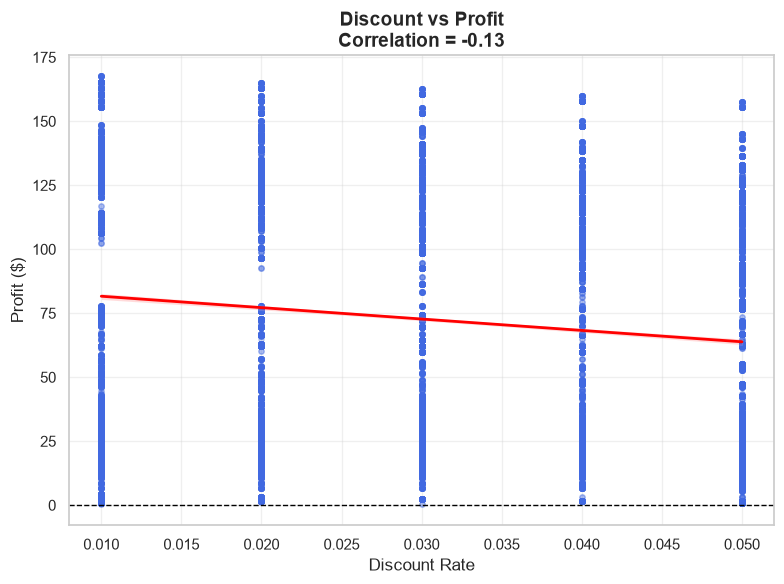

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation
correlation_dp = df['Discount'].corr(df['Profit'])

plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x='Discount',
    y='Profit',
    scatter_kws={
        'alpha': 0.25,
        's': 15,
        'color': 'royalblue'
    },
    line_kws={
        'color': 'red',
        'linewidth': 2
    }
)

plt.axhline(y=0, color='black', linestyle='--', linewidth=1)

plt.title(f'Discount vs Profit\nCorrelation = {correlation_dp:.2f}',
          fontsize=14,
          fontweight='bold')
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

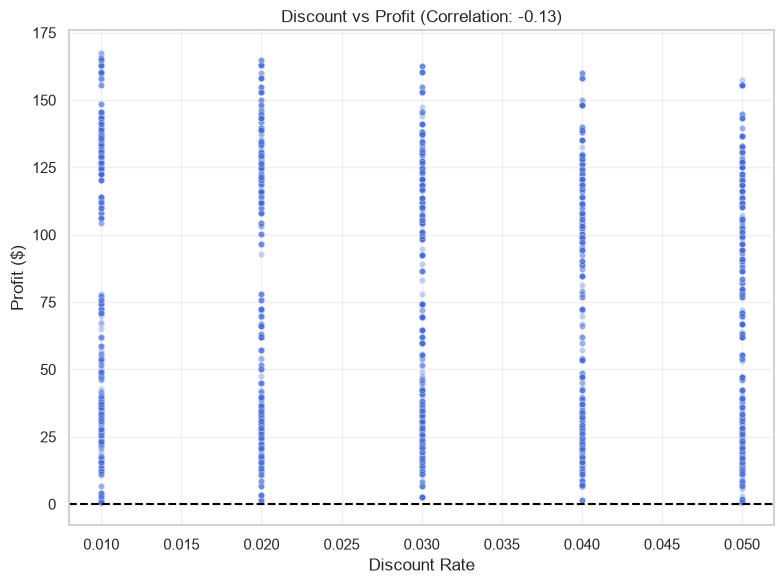

In [24]:
sample_df = df.sample(min(3000, len(df)), random_state=42)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=sample_df,
    x='Discount',
    y='Profit',
    alpha=0.3,
    s=20,
    color='royalblue'
)

plt.axhline(0, color='black', linestyle='--')
plt.title(f'Discount vs Profit (Correlation: {correlation_dp:.2f})')
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

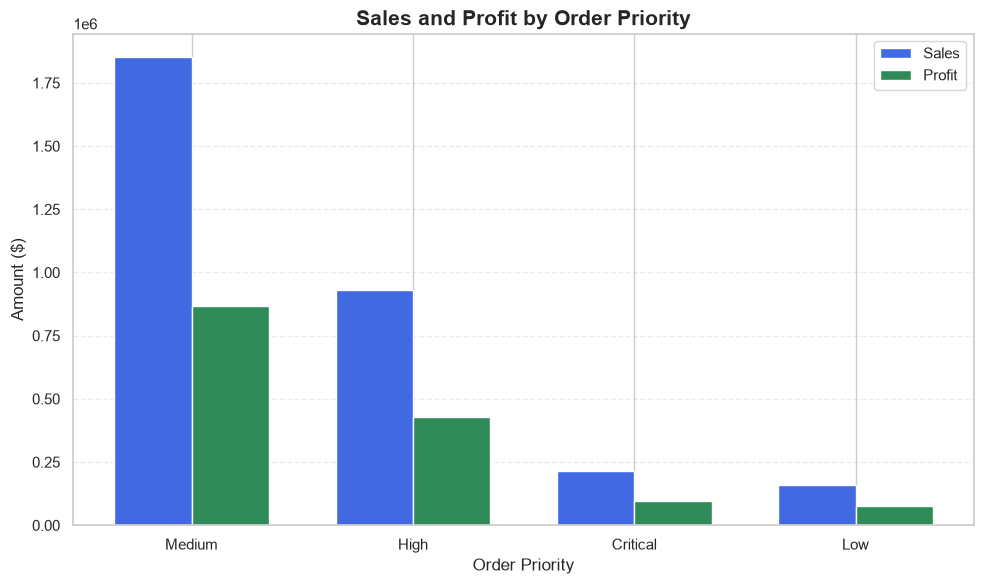

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Order Priority Analysis
priority_analysis = (
    df.groupby('Order Priority', observed=True)
      .agg({'Sales': 'sum', 'Profit': 'sum'})
      .sort_values(by='Sales', ascending=False)
      .reset_index()
)

x = np.arange(len(priority_analysis))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2,
        priority_analysis['Sales'],
        width,
        label='Sales',
        color='royalblue')

plt.bar(x + width/2,
        priority_analysis['Profit'],
        width,
        label='Profit',
        color='seagreen')

plt.xticks(x, priority_analysis['Order Priority'])
plt.title('Sales and Profit by Order Priority', fontsize=15, fontweight='bold')
plt.xlabel('Order Priority')
plt.ylabel('Amount ($)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

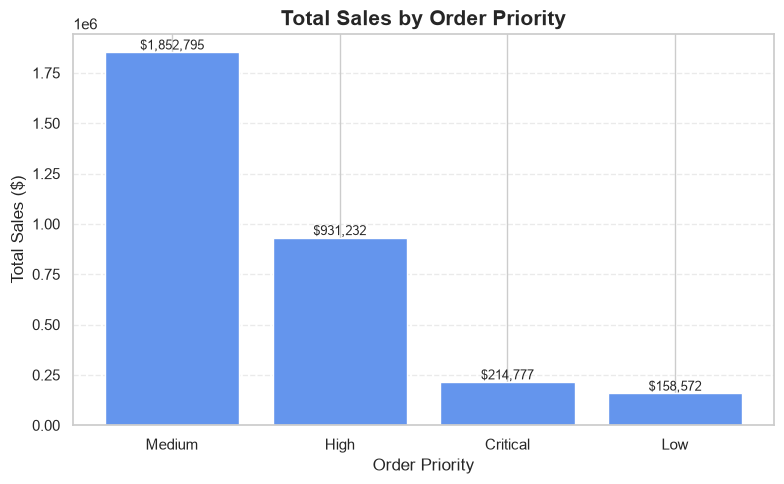

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.bar(
    priority_analysis['Order Priority'],
    priority_analysis['Sales'],
    color='cornflowerblue'
)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Total Sales by Order Priority', fontsize=15, fontweight='bold')
plt.xlabel('Order Priority')
plt.ylabel('Total Sales ($)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

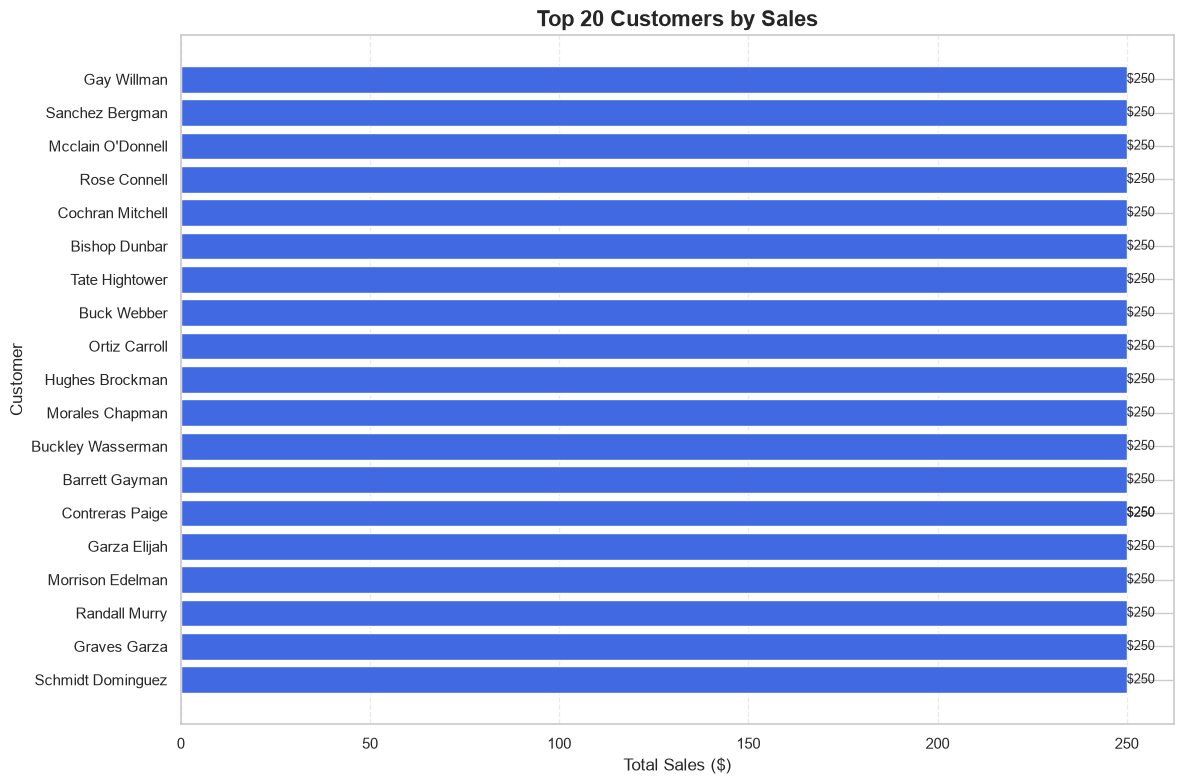

In [27]:
import matplotlib.pyplot as plt

# Customer Analysis
customer_analysis = (
    df.groupby(['Customer ID', 'Customer Name'], observed=True)
      .agg({'Sales': 'sum', 'Profit': 'sum'})
      .reset_index()
)

# Top 20 by Sales
top_sales = (
    customer_analysis.sort_values(by='Sales', ascending=False)
    .head(20)
    .sort_values(by='Sales')
)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    top_sales['Customer Name'],
    top_sales['Sales'],
    color='royalblue'
)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"${bar.get_width():,.0f}",
        va='center',
        fontsize=9
    )

plt.title("Top 20 Customers by Sales", fontsize=16, fontweight='bold')
plt.xlabel("Total Sales ($)")
plt.ylabel("Customer")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

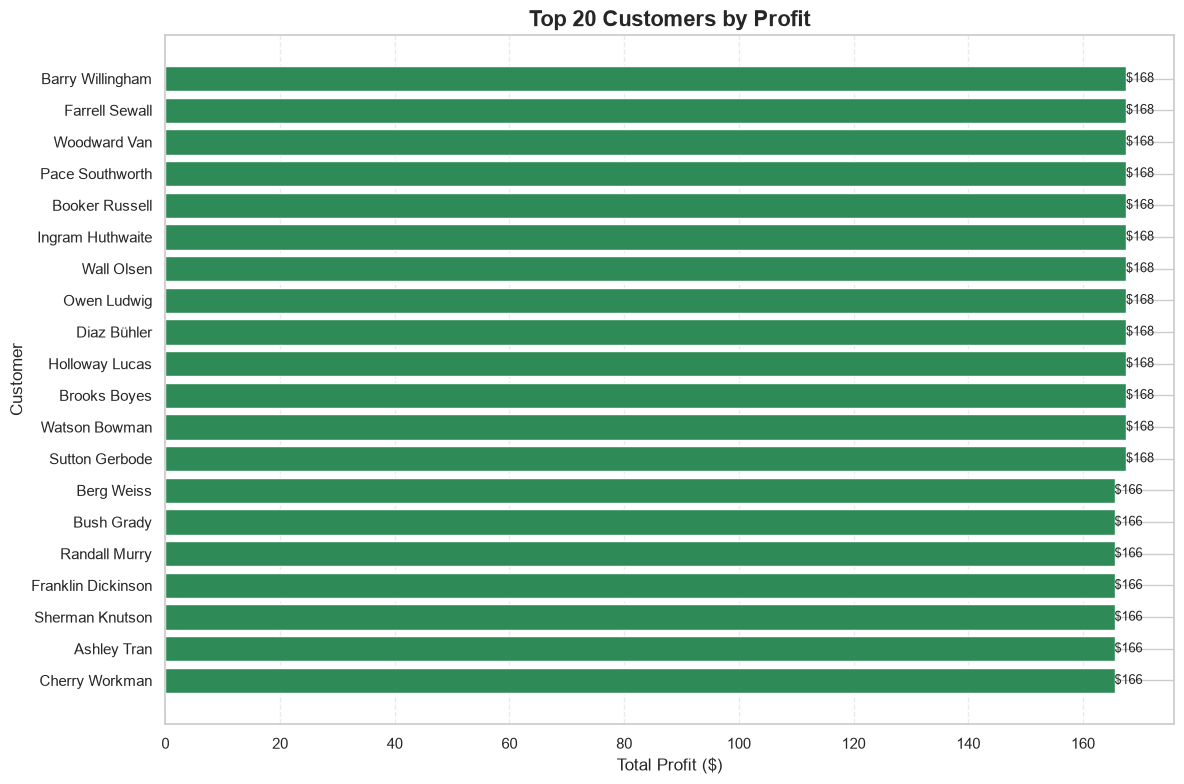

In [28]:
# Top 20 by Profit
top_profit = (
    customer_analysis.sort_values(by='Profit', ascending=False)
    .head(20)
    .sort_values(by='Profit')
)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    top_profit['Customer Name'],
    top_profit['Profit'],
    color='seagreen'
)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"${bar.get_width():,.0f}",
        va='center',
        fontsize=9
    )

plt.title("Top 20 Customers by Profit", fontsize=16, fontweight='bold')
plt.xlabel("Total Profit ($)")
plt.ylabel("Customer")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

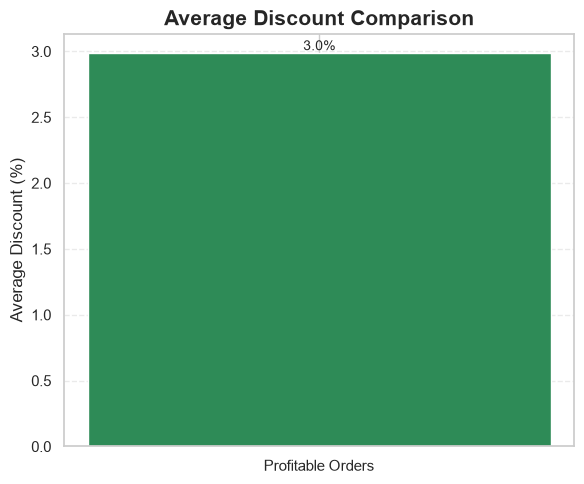

In [30]:
import matplotlib.pyplot as plt

avg_discount = [
    loss_orders['Discount'].mean() * 100,
    df[df['Profit'] >= 0]['Discount'].mean() * 100
]

labels = ['Loss Orders', 'Profitable Orders']

plt.figure(figsize=(6, 5))

bars = plt.bar(labels, avg_discount, color=['crimson', 'seagreen'])

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Average Discount Comparison", fontsize=15, fontweight='bold')
plt.ylabel("Average Discount (%)")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

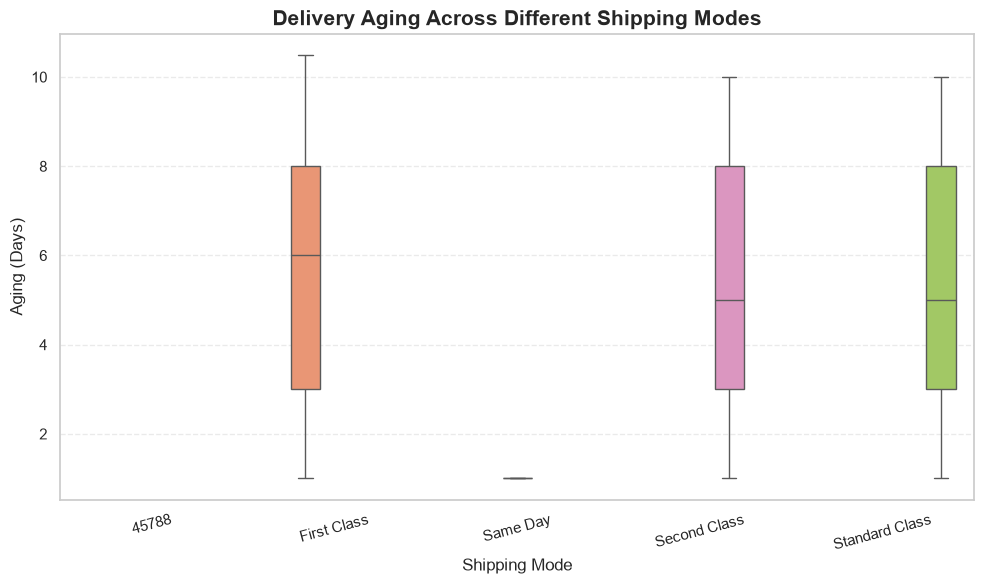

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Ship Mode',
    y='Aging',
    hue='Ship Mode',      # For Seaborn 0.14+
    palette='Set2',
    legend=False
)

plt.title("Delivery Aging Across Different Shipping Modes", fontsize=15, fontweight='bold')
plt.xlabel("Shipping Mode", fontsize=12)
plt.ylabel("Aging (Days)", fontsize=12)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

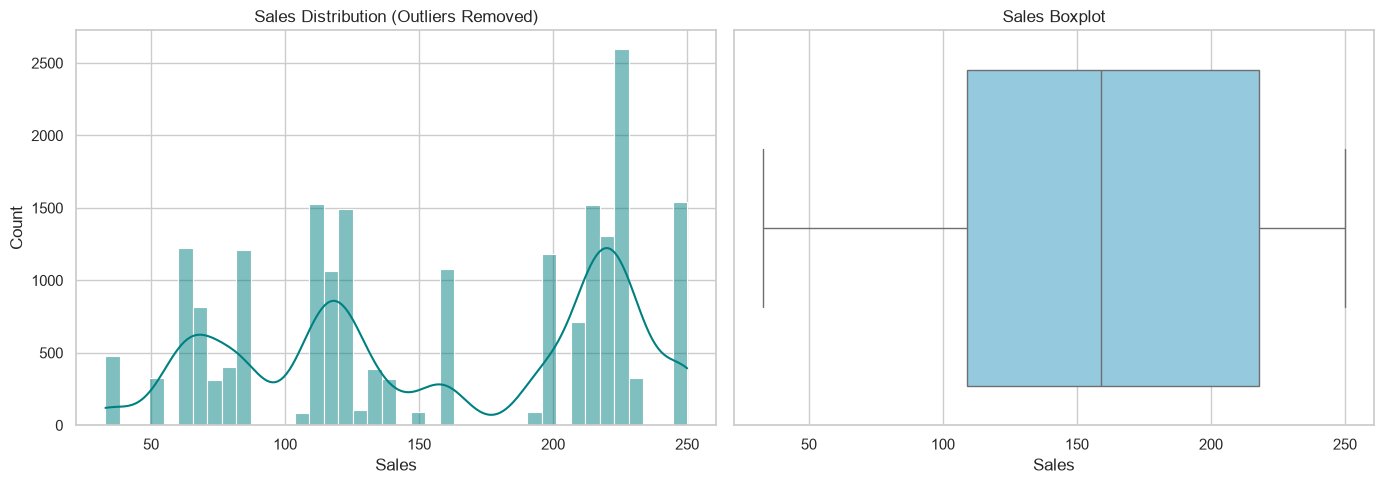

In [34]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

sales_filtered = df[
    (df['Sales'] >= Q1 - 1.5 * IQR) &
    (df['Sales'] <= Q3 + 1.5 * IQR)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    sales_filtered['Sales'],
    bins=40,
    kde=True,
    ax=axes[0],
    color='teal'
)
axes[0].set_title('Sales Distribution (Outliers Removed)')

sns.boxplot(
    x=sales_filtered['Sales'],
    ax=axes[1],
    color='skyblue'
)
axes[1].set_title('Sales Boxplot')

plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

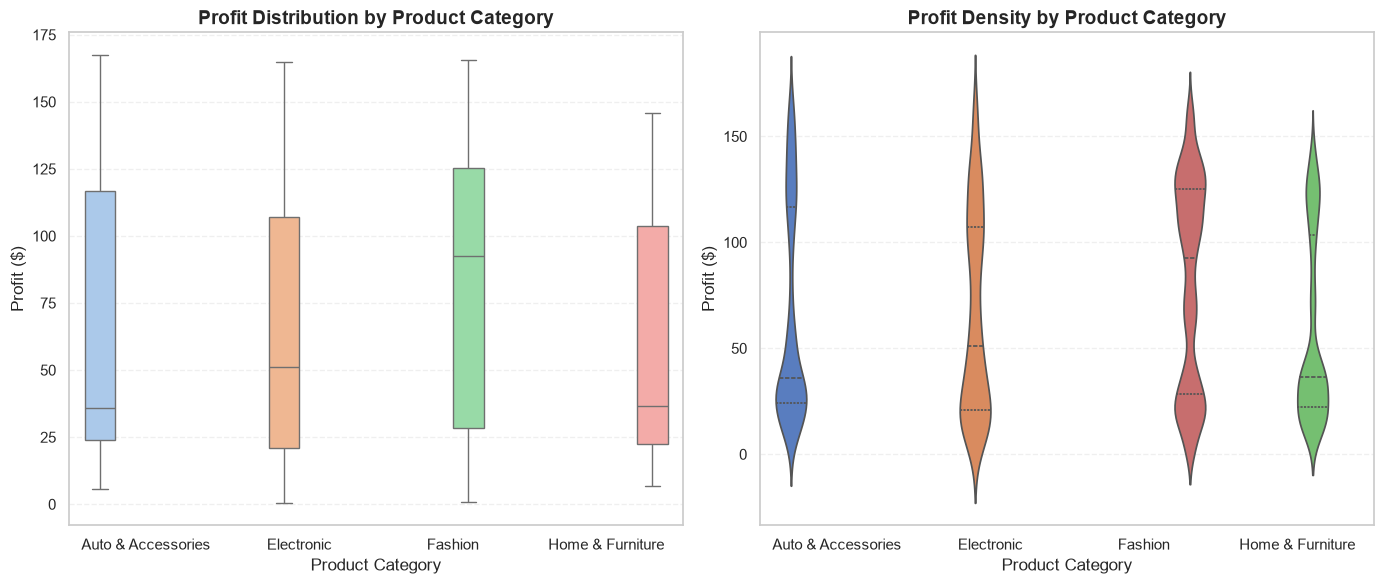

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(
    data=df,
    x='Product Category',
    y='Profit',
    hue='Product Category',      # For Seaborn 0.14+
    palette='pastel',
    showfliers=False,            # Hide extreme outliers
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Profit Distribution by Product Category',
                  fontsize=14,
                  fontweight='bold')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Profit ($)')
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

# Violin Plot
sns.violinplot(
    data=df,
    x='Product Category',
    y='Profit',
    hue='Product Category',
    palette='muted',
    legend=False,
    inner='quartile',            # Show quartiles
    ax=axes[1]
)

axes[1].set_title('Profit Density by Product Category',
                  fontsize=14,
                  fontweight='bold')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Profit ($)')
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

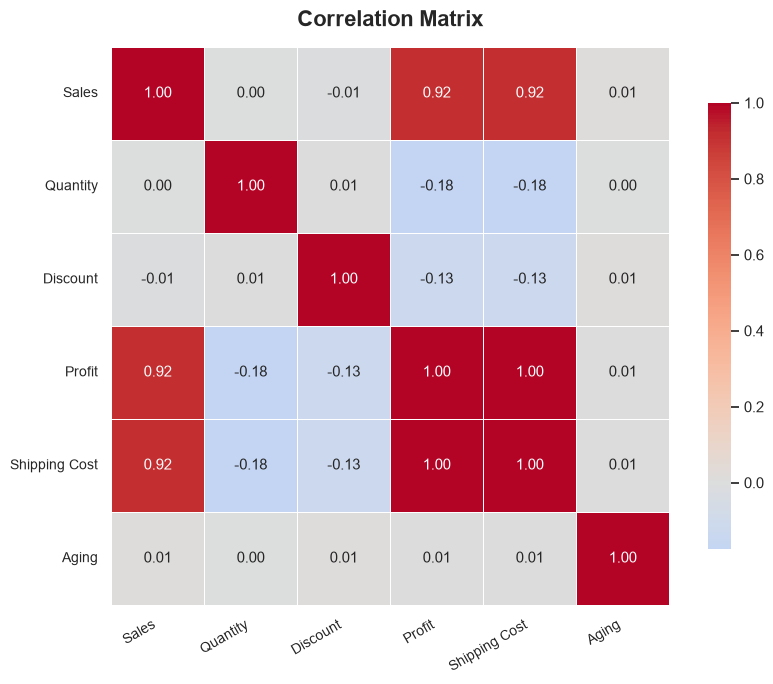

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix
corr_matrix = df[['Sales', 'Quantity', 'Discount', 'Profit',
                  'Shipping Cost', 'Aging']].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,                 # Center colors at zero
    linewidths=0.5,           # Grid lines
    linecolor="white",
    square=True,
    annot_kws={"size": 11},   # Annotation font size
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix", fontsize=16, fontweight="bold", pad=15)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

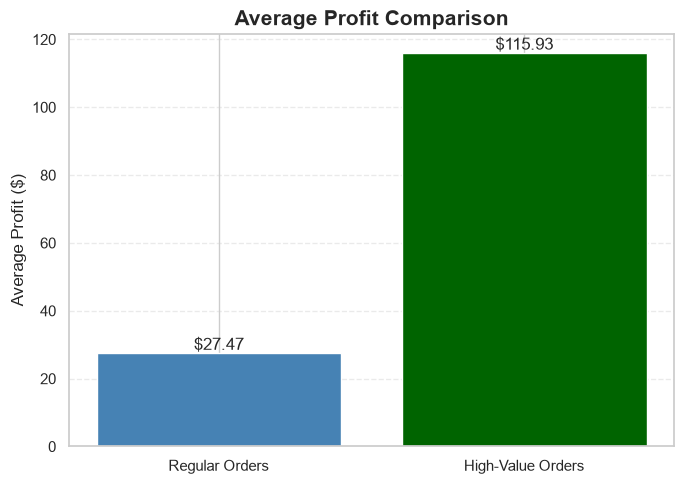

In [38]:
import matplotlib.pyplot as plt

comparison = [
    df[df['Sales'] <= avg_sales]['Profit'].mean(),
    high_value_orders['Profit'].mean()
]

labels = ['Regular Orders', 'High-Value Orders']

plt.figure(figsize=(7, 5))

bars = plt.bar(labels, comparison, color=['steelblue', 'darkgreen'])

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"${bar.get_height():,.2f}",
        ha='center',
        va='bottom'
    )

plt.title("Average Profit Comparison", fontsize=15, fontweight='bold')
plt.ylabel("Average Profit ($)")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

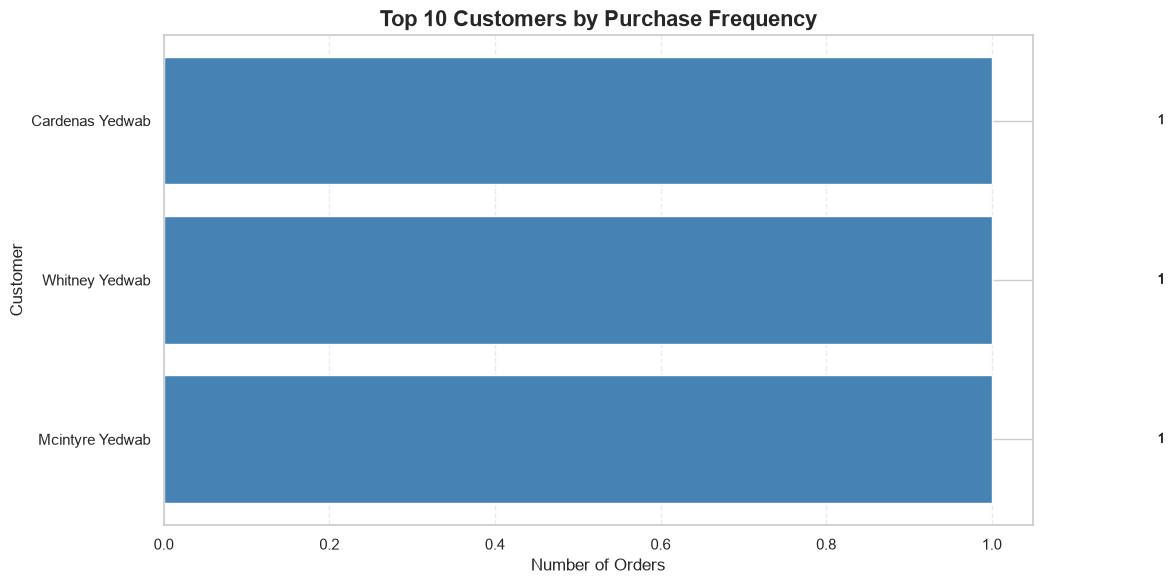

In [39]:
import matplotlib.pyplot as plt

# Customer Purchase Frequency
cust_freq = (
    df.groupby(['Customer ID', 'Customer Name'], observed=True)
      .agg(
          Order_Count=('Order ID', 'nunique'),
          Total_Sales=('Sales', 'sum')
      )
      .reset_index()
)

cust_freq['Avg_Order_Value'] = (
    cust_freq['Total_Sales'] / cust_freq['Order_Count']
)

# Top 10 frequent customers
top_customers = (
    cust_freq.sort_values(by='Order_Count', ascending=False)
             .head(10)
             .sort_values(by='Order_Count')
)

plt.figure(figsize=(12, 6))

bars = plt.barh(
    top_customers['Customer Name'],
    top_customers['Order_Count'],
    color='steelblue'
)

# Value labels
for bar in bars:
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height()/2,
        f"{int(bar.get_width())}",
        va='center',
        fontsize=10
    )

plt.title("Top 10 Customers by Purchase Frequency",
          fontsize=16,
          fontweight='bold')
plt.xlabel("Number of Orders")
plt.ylabel("Customer")
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

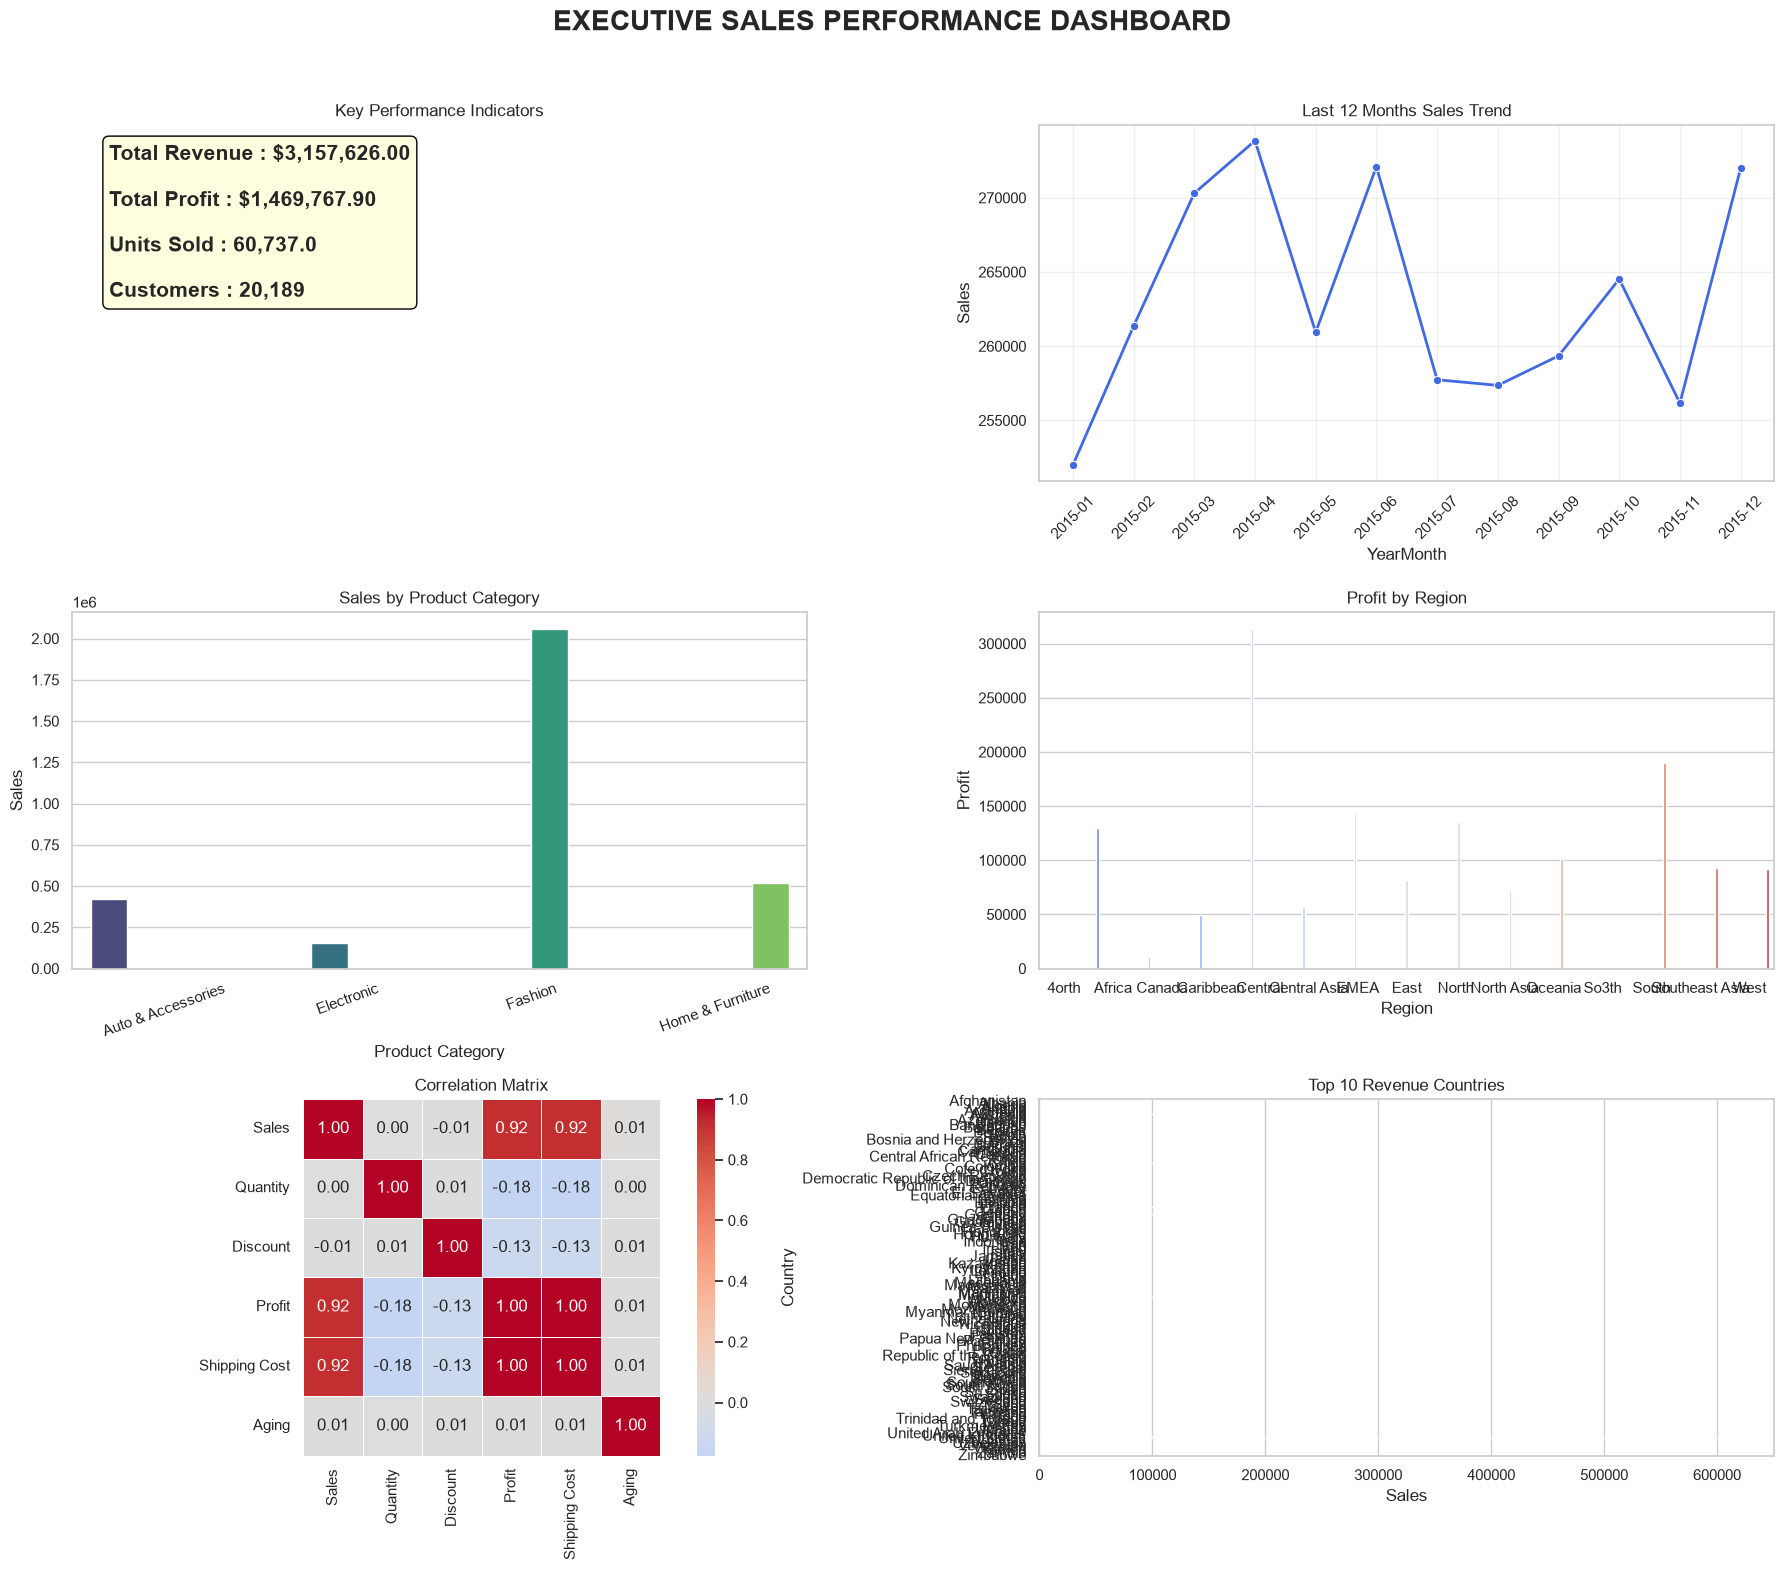

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Summary Metrics
# -----------------------------
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_quantity = df['Quantity'].sum()
total_customers = df['Customer ID'].nunique()

# -----------------------------
# Data Preparation
# -----------------------------
category_analysis = (
    df.groupby('Product Category', observed=True)['Sales']
      .sum()
      .reset_index()
)

regional_analysis = (
    df.groupby('Region', observed=True)['Profit']
      .sum()
      .reset_index()
)

top_10_countries = (
    df.groupby('Country', observed=True)['Sales']
      .sum()
      .reset_index()
      .sort_values(by='Sales', ascending=False)
      .head(10)
)

monthly_trend = (
    df.groupby('YearMonth', observed=True)['Sales']
      .sum()
      .reset_index()
)

corr_matrix = df[['Sales', 'Quantity', 'Discount',
                  'Profit', 'Shipping Cost', 'Aging']].corr()

# -----------------------------
# Dashboard
# -----------------------------
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
fig.suptitle(
    "EXECUTIVE SALES PERFORMANCE DASHBOARD",
    fontsize=20,
    fontweight='bold'
)

# ---------------- KPI ----------------
axes[0, 0].axis('off')

kpi_text = (
    f"Total Revenue : ${total_sales:,.2f}\n\n"
    f"Total Profit : ${total_profit:,.2f}\n\n"
    f"Units Sold : {total_quantity:,}\n\n"
    f"Customers : {total_customers:,}"
)

axes[0, 0].text(
    0.05,
    0.95,
    kpi_text,
    fontsize=15,
    fontweight='bold',
    va='top',
    bbox=dict(facecolor='lightyellow',
              edgecolor='black',
              boxstyle='round')
)

axes[0, 0].set_title("Key Performance Indicators")

# ---------------- Monthly Trend ----------------
sns.lineplot(
    data=monthly_trend.tail(12),
    x='YearMonth',
    y='Sales',
    marker='o',
    color='royalblue',
    linewidth=2,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Last 12 Months Sales Trend")
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(alpha=0.3)

# ---------------- Category Sales ----------------
sns.barplot(
    data=category_analysis,
    x='Product Category',
    y='Sales',
    hue='Product Category',
    palette='viridis',
    legend=False,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Sales by Product Category")
axes[1, 0].tick_params(axis='x', rotation=20)

# ---------------- Regional Profit ----------------
sns.barplot(
    data=regional_analysis,
    x='Region',
    y='Profit',
    hue='Region',
    palette='coolwarm',
    legend=False,
    ax=axes[1, 1]
)

axes[1, 1].set_title("Profit by Region")

# ---------------- Correlation Heatmap ----------------
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar=True,
    ax=axes[2, 0]
)

axes[2, 0].set_title("Correlation Matrix")

# ---------------- Top 10 Countries ----------------
sns.barplot(
    data=top_10_countries,
    x='Sales',
    y='Country',
    hue='Country',
    palette='rocket',
    legend=False,
    ax=axes[2, 1]
)

axes[2, 1].set_title("Top 10 Revenue Countries")

# ---------------- Layout ----------------
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()